# 데이터 로드

## [Audit 반영] 한글 폰트 설정

모든 시각화에서 한글 글자 깨짐을 방지하기 위해 Malgun Gothic 폰트를 적용합니다.

In [1]:
# [Audit 반영] 한글 폰트 설정 — 모든 시각화에서 한글 글자 깨짐 방지
from font_helper import setup_korean_font
setup_korean_font()

[font_helper] 한글 폰트 적용: Malgun Gothic (axes.unicode_minus=False)


'Malgun Gothic'

In [2]:
import pandas as pd
import os

# 프로젝트 기준 경로 설정
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

data_DOWNSIZE = pd.read_pickle(os.path.join(BASE_DIR, 'df_fixed.pkl.gz'))
display(data_DOWNSIZE.head())

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_55,일조_56,일조_57,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,Unnamed: 2,JDGMNT_WORD_NAME_encoded
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.2,7.3,9.9,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,10.4,10.2,9.6,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,1.4,10.1,6.2,8.5,9.3,적합,불검출,0,건강기능식품(제품),0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,10.1,6.2,8.5,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.9,6.5,7.7,8.6,8.7,적합,불검출,0,농산가공식품류,0


# 특성공학

Reference-based Aflatoxin Model Comparison Analysis
with Optimal Threshold Tuning

Step 1: Train and evaluate model with basic data

Data preprocessing started...
One-hot encoding features (split 이후 적용): ['INSPCT_PURPS_NAME', 'Unnamed: 2']
Train data shape: (60700, 630)
Val   data shape: (7322, 630)
Test  data shape: (12861, 630)
Train 'Non-compliant' ratio: 0.003657
Val   'Non-compliant' ratio: 0.004234
Test  'Non-compliant' ratio: 0.004899

Basic RandomForest model training started...



Optimal Threshold Search:
  Metric: F1
  Optimal Threshold: 0.0100
  Best F1 Score: 0.004648

Basic RandomForest Model Evaluation Results:
--------------------------------------------------
Training time: 4.70s
Optimal Threshold (chosen on VAL): 0.0100
Best F1 on VAL:                    0.004648
Accuracy:     0.747376
Precision:    0.003738
Recall:       0.190476
F1-Score:     0.007333
AP Score:     0.004734
ROC-AUC:      0.471972
--------------------------------------------------

Step 2: Apply reference-based feature engineering


Simple Reference-based Feature Engineering (3 features)
Original features: 610

1. Optimal temperature days for toxin production...
   - Reference: FAO, 2001

2. Low humidity days...
   - Reference: Gangneung-Wonju National University, 2014

3. Consecutive dry days...
   - Reference: Bowen & Hagan, 2015



Reference-based Feature Engineering Complete!
Original features: 610
Total features: 613
New features: 3

Generated features:
   1. drought_stress_7d
   2. low_humid_days_7d
   3. optimal_temp_days_7d

Data preprocessing started...
One-hot encoding features (split 이후 적용): ['INSPCT_PURPS_NAME', 'Unnamed: 2']
Train data shape: (60700, 633)
Val   data shape: (7322, 633)
Test  data shape: (12861, 633)
Train 'Non-compliant' ratio: 0.003657
Val   'Non-compliant' ratio: 0.004234
Test  'Non-compliant' ratio: 0.004899

Reference-based Enhanced RandomForest model training started...



Optimal Threshold Search:
  Metric: F1
  Optimal Threshold: 0.0100
  Best F1 Score: 0.004040

Reference-based Enhanced RandomForest Model Evaluation Results:
--------------------------------------------------
Training time: 5.01s
Optimal Threshold (chosen on VAL): 0.0100
Best F1 on VAL:                    0.004040
Accuracy:     0.743644
Precision:    0.005505
Recall:       0.285714
F1-Score:     0.010801
AP Score:     0.005090
ROC-AUC:      0.516573
--------------------------------------------------

Step 3: Model performance comparison

Reference-based Feature Engineering Model Comparison
   Metric Basic Model Enhanced Model Improvement Improvement %
 ACCURACY    0.747376       0.743644   -0.003732      -0.4994%
PRECISION    0.003738       0.005505   +0.001766     +47.2477%
   RECALL    0.190476       0.285714   +0.095238     +50.0000%
       F1    0.007333       0.010801   +0.003468     +47.2997%
 AP_SCORE    0.004734       0.005090   +0.000356      +7.5293%
  ROC_AUC    0.471972   

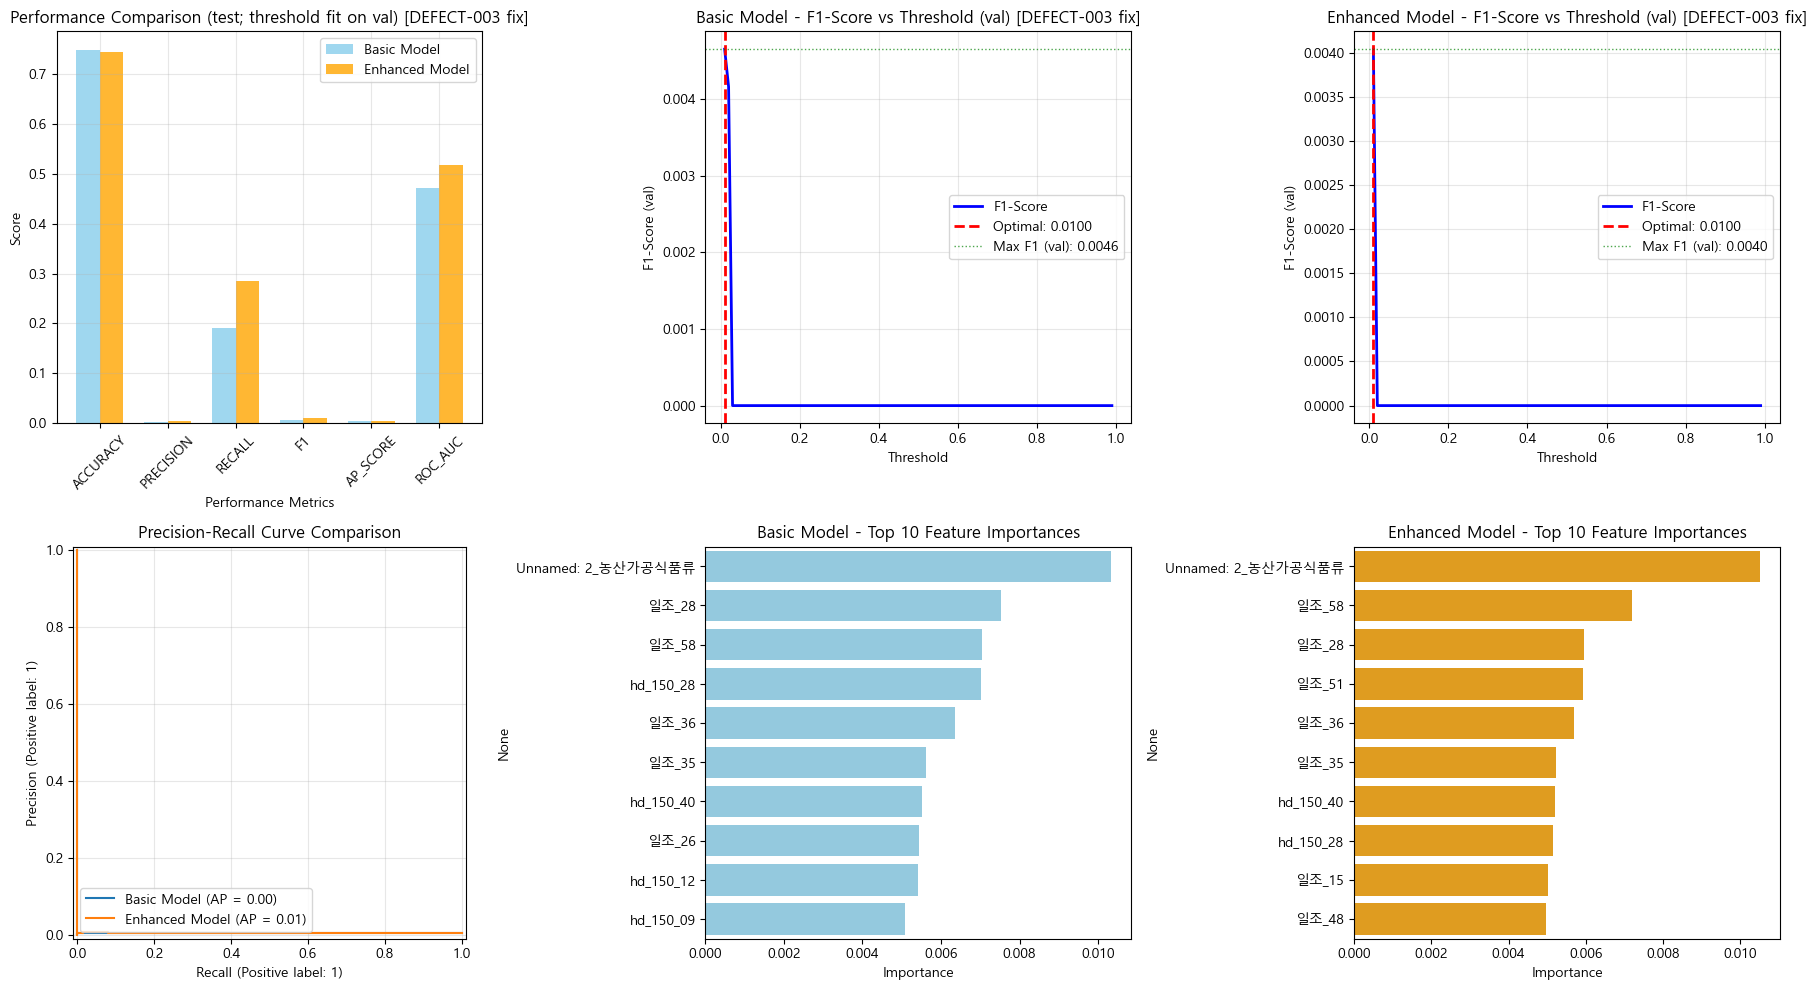


Reference-based Analysis Complete!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    PrecisionRecallDisplay,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Global settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def find_optimal_threshold(y_true, y_pred_proba, metric='f1', verbose=True):
    """
    Find optimal threshold that maximizes the specified metric

    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities
    metric : str
        Metric to optimize ('f1', 'precision', 'recall')
    verbose : bool
        Print detailed information

    Returns:
    --------
    optimal_threshold : float
        Optimal threshold value
    best_score : float
        Best score achieved
    """
    thresholds = np.linspace(0.01, 0.99, 99)
    scores = []

    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)

        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        scores.append(score)

    optimal_idx = np.argmax(scores)
    optimal_threshold = thresholds[optimal_idx]
    best_score = scores[optimal_idx]

    if verbose:
        print(f"\nOptimal Threshold Search:")
        print(f"  Metric: {metric.upper()}")
        print(f"  Optimal Threshold: {optimal_threshold:.4f}")
        print(f"  Best {metric.upper()} Score: {best_score:.6f}")

    return optimal_threshold, best_score, thresholds, scores

def create_simple_reference_features(data_DOWNSIZE, verbose=True):
    """
    Memory-efficient simple reference-based feature engineering
    Generate only 3 core features
    """
    df = data_DOWNSIZE.copy()
    original_columns = set(df.columns)

    if verbose:
        print("="*60)
        print("Simple Reference-based Feature Engineering (3 features)")
        print("="*60)
        print(f"Original features: {len(original_columns)}")

    window = 7

    # 1. Optimal temperature days for toxin production (25-35°C)
    if verbose:
        print("\n1. Optimal temperature days for toxin production...")
        print("   - Reference: FAO, 2001")

    temp_cols = [f'tmprt_150_{i:02d}' for i in range(window) if f'tmprt_150_{i:02d}' in df.columns]

    if temp_cols:
        temp_data = df[temp_cols].values
        optimal_temp_days = np.sum((temp_data >= 25) & (temp_data <= 35), axis=1)
        df['optimal_temp_days_7d'] = optimal_temp_days

    # 2. Low humidity days (<60%)
    if verbose:
        print("\n2. Low humidity days...")
        print("   - Reference: Gangneung-Wonju National University, 2014")

    humid_cols = [f'hd_150_{i:02d}' for i in range(window) if f'hd_150_{i:02d}' in df.columns]

    if humid_cols:
        humid_data = df[humid_cols].values
        low_humid_days = np.sum(humid_data < 60, axis=1)
        df['low_humid_days_7d'] = low_humid_days

    # 3. Consecutive dry days
    if verbose:
        print("\n3. Consecutive dry days...")
        print("   - Reference: Bowen & Hagan, 2015")

    rain_cols = [f'afp_{i:02d}' for i in range(window) if f'afp_{i:02d}' in df.columns]

    if rain_cols:
        rain_data = df[rain_cols].values
        drought_stress = np.zeros(len(df))
        for i in range(len(df)):
            row = rain_data[i]
            max_consecutive_dry = 0
            current_consecutive = 0
            for val in row:
                if np.isnan(val) or val == 0:
                    current_consecutive += 1
                    max_consecutive_dry = max(max_consecutive_dry, current_consecutive)
                else:
                    current_consecutive = 0
            drought_stress[i] = max_consecutive_dry

        df['drought_stress_7d'] = drought_stress

    new_columns = set(df.columns) - original_columns

    if verbose:
        print("\n" + "="*60)
        print("Reference-based Feature Engineering Complete!")
        print("="*60)
        print(f"Original features: {len(original_columns)}")
        print(f"Total features: {len(df.columns)}")
        print(f"New features: {len(new_columns)}")

        print(f"\nGenerated features:")
        for i, feature in enumerate(sorted(new_columns), 1):
            print(f"  {i:2d}. {feature}")
        print("="*60)

    feature_info = {
        'original_features': list(original_columns),
        'new_features': list(new_columns),
        'total_original': len(original_columns),
        'total_new': len(new_columns),
        'total_final': len(df.columns)
    }

    return df, feature_info

def prepare_data(data_DOWNSIZE, verbose=True):
    """Data preprocessing and splitting"""
    if verbose:
        print("\nData preprocessing started...")

    TARGET = 'JDGMNT_WORD_NAME_encoded'
    COLS_TO_DROP = ['결과값', '결과', 'JDGMNT_WORD_NAME', '사용주소', 'PRDLST_NM', 'x_coord', 'y_coord', TARGET]

    X = data_DOWNSIZE.drop(columns=COLS_TO_DROP)
    y = data_DOWNSIZE[TARGET]

    # F-01 fix: split FIRST, then one-hot encode train and align test to train columns.
    # 이전에는 split 이전에 pd.get_dummies를 호출하여 test의 카테고리 분포가
    # train의 인코딩 형상에 영향을 주는 누수가 있었음.
    categorical_features = list(X.select_dtypes(include=['object']).columns)
    if verbose:
        print(f"One-hot encoding features (split 이후 적용): {categorical_features}")

    positive_indices = y[y == 1].index

    # [DEFECT-003 fix] train/val/test 3-way split. val fold 가 train 으로부터 분리되어
    # 임계치 fit 에 사용 → test 라벨이 임계치 결정에 새지 않게 보장. positive 기준 70/10/20
    # (전체 positive 의 0~70% train, 70~80% val, 80~100% test). 시간순 positive-aware 의미 보존.
    if len(positive_indices) < 5:
        n = len(X)
        sp_train = int(n * 0.7)
        sp_val   = int(n * 0.8)
        X_train_raw = X.iloc[:sp_train]
        y_train     = y.iloc[:sp_train]
        X_val_raw   = X.iloc[sp_train:sp_val]
        y_val       = y.iloc[sp_train:sp_val]
        X_test_raw  = X.iloc[sp_val:]
        y_test      = y.iloc[sp_val:]
    else:
        positive_test_split_idx = int(len(positive_indices) * 0.8)  # (train+val) | test
        positive_val_split_idx  = int(len(positive_indices) * 0.7)  # train | val (within train+val)
        test_anchor             = positive_indices[positive_test_split_idx]
        val_anchor              = positive_indices[positive_val_split_idx]
        boundary_to_test        = X.index.get_loc(test_anchor)
        boundary_to_val         = X.index.get_loc(val_anchor)

        X_train_raw = X.iloc[:boundary_to_val + 1]
        y_train     = y.iloc[:boundary_to_val + 1]
        X_val_raw   = X.iloc[boundary_to_val + 1:boundary_to_test + 1]
        y_val       = y.iloc[boundary_to_val + 1:boundary_to_test + 1]
        X_test_raw  = X.iloc[boundary_to_test + 1:]
        y_test      = y.iloc[boundary_to_test + 1:]

    # train 한정 one-hot fit, val/test 는 train 의 컬럼 시그니처로 reindex
    # train 에 없던 카테고리는 자연스럽게 drop, train 컬럼 누락은 0 채움
    X_train = pd.get_dummies(X_train_raw, columns=categorical_features, dummy_na=False)
    X_val   = pd.get_dummies(X_val_raw,   columns=categorical_features, dummy_na=False)
    X_test  = pd.get_dummies(X_test_raw,  columns=categorical_features, dummy_na=False)
    X_val   = X_val.reindex(columns=X_train.columns,  fill_value=0)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    if X_test.empty or y_test.empty or X_val.empty or y_val.empty:
        if verbose:
            print("Error: Val/Test set is empty.")
        return None, None, None, None, None, None
    else:
        if verbose:
            print(f"Train data shape: {X_train.shape}")
            print(f"Val   data shape: {X_val.shape}")
            print(f"Test  data shape: {X_test.shape}")
            print(f"Train 'Non-compliant' ratio: {y_train.mean():.6f}")
            print(f"Val   'Non-compliant' ratio: {y_val.mean():.6f}")
            print(f"Test  'Non-compliant' ratio: {y_test.mean():.6f}")

    return X_train, X_val, X_test, y_train, y_val, y_test

def train_and_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, model_name="RandomForest", verbose=True):
    """Train RF, fit threshold on VAL, report final metrics on TEST. [DEFECT-003 fix]

    find_optimal_threshold 가 val 라벨을 받아 임계치 결정 → test 라벨 누수 제거.
    accuracy/precision/recall/f1/ap/roc-auc 는 test 기준 그대로 보고.
    """
    if verbose:
        print(f"\n{model_name} model training started...")

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    )

    start_time = time.time()
    rf_model.fit(X_train, y_train)
    end_time = time.time()

    # Predict probabilities on VAL (for threshold fit) and TEST (for final report)
    y_pred_proba_val  = rf_model.predict_proba(X_val)[:, 1]
    y_pred_proba_test = rf_model.predict_proba(X_test)[:, 1]

    # [DEFECT-003 fix] threshold 는 VAL 로 결정 (이전: y_test 사용 → 누수).
    optimal_threshold, best_f1_val, thresholds, f1_scores_val = find_optimal_threshold(
        y_val, y_pred_proba_val, metric='f1', verbose=verbose
    )

    # Predict on TEST with VAL-chosen threshold
    y_pred_test = (y_pred_proba_test >= optimal_threshold).astype(int)

    # Calculate metrics on TEST (with val-chosen threshold)
    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    recall = recall_score(y_test, y_pred_test, zero_division=0)
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    ap_score = average_precision_score(y_test, y_pred_proba_test)
    roc_auc = roc_auc_score(y_test, y_pred_proba_test)

    results = {
        'model': rf_model,
        'y_pred': y_pred_test,
        'y_pred_proba': y_pred_proba_test,
        'y_pred_proba_val': y_pred_proba_val,
        'optimal_threshold': optimal_threshold,
        'best_f1_val': best_f1_val,
        'thresholds': thresholds,
        'f1_scores': f1_scores_val,  # val 기준 F1-vs-threshold 곡선 (시각화용)
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'ap_score': ap_score,
        'roc_auc': roc_auc,
        'training_time': end_time - start_time
    }

    if verbose:
        print(f"\n{model_name} Model Evaluation Results:")
        print("-" * 50)
        print(f"Training time: {end_time - start_time:.2f}s")
        print(f"Optimal Threshold (chosen on VAL): {optimal_threshold:.4f}")
        print(f"Best F1 on VAL:                    {best_f1_val:.6f}")
        print(f"Accuracy:     {accuracy:.6f}")
        print(f"Precision:    {precision:.6f}")
        print(f"Recall:       {recall:.6f}")
        print(f"F1-Score:     {f1:.6f}")
        print(f"AP Score:     {ap_score:.6f}")
        print(f"ROC-AUC:      {roc_auc:.6f}")
        print("-" * 50)

    return results

def compare_models(basic_results, enhanced_results, X_test_basic, X_test_enhanced, y_test, verbose=True):
    """Compare model performance"""
    if verbose:
        print("\n" + "="*60)
        print("Reference-based Feature Engineering Model Comparison")
        print("="*60)

    metrics = ['accuracy', 'precision', 'recall', 'f1', 'ap_score', 'roc_auc']
    comparison_data = []

    for metric in metrics:
        basic_score = basic_results[metric]
        enhanced_score = enhanced_results[metric]
        improvement = enhanced_score - basic_score
        improvement_pct = (improvement / basic_score * 100) if basic_score != 0 else 0

        comparison_data.append({
            'Metric': metric.upper(),
            'Basic Model': f"{basic_score:.6f}",
            'Enhanced Model': f"{enhanced_score:.6f}",
            'Improvement': f"{improvement:+.6f}",
            'Improvement %': f"{improvement_pct:+.4f}%"
        })

    comparison_df = pd.DataFrame(comparison_data)

    if verbose:
        print(comparison_df.to_string(index=False))
        print(f"\nBasic Model Optimal Threshold: {basic_results['optimal_threshold']:.4f}")
        print(f"Enhanced Model Optimal Threshold: {enhanced_results['optimal_threshold']:.4f}")
        print("="*60)

    # Visualization
    fig = plt.figure(figsize=(18, 10))

    # 1. Performance metrics comparison
    ax1 = plt.subplot(2, 3, 1)
    metrics_names = [row['Metric'] for row in comparison_data]
    basic_scores = [float(row['Basic Model']) for row in comparison_data]
    enhanced_scores = [float(row['Enhanced Model']) for row in comparison_data]

    x = np.arange(len(metrics_names))
    width = 0.35

    ax1.bar(x - width/2, basic_scores, width, label='Basic Model', alpha=0.8, color='skyblue')
    ax1.bar(x + width/2, enhanced_scores, width, label='Enhanced Model', alpha=0.8, color='orange')
    ax1.set_xlabel('Performance Metrics')
    ax1.set_ylabel('Score')
    ax1.set_title('Performance Comparison (test; threshold fit on val) [DEFECT-003 fix]')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. F1-Score vs Threshold (Basic Model)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(basic_results['thresholds'], basic_results['f1_scores'],
             'b-', linewidth=2, label='F1-Score')
    ax2.axvline(basic_results['optimal_threshold'], color='r',
                linestyle='--', linewidth=2, label=f"Optimal: {basic_results['optimal_threshold']:.4f}")
    ax2.axhline(basic_results['best_f1_val'], color='g',
                linestyle=':', linewidth=1, alpha=0.7, label=f"Max F1 (val): {basic_results['best_f1_val']:.4f}")
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('F1-Score (val)')
    ax2.set_title('Basic Model - F1-Score vs Threshold (val) [DEFECT-003 fix]')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. F1-Score vs Threshold (Enhanced Model)
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(enhanced_results['thresholds'], enhanced_results['f1_scores'],
             'b-', linewidth=2, label='F1-Score')
    ax3.axvline(enhanced_results['optimal_threshold'], color='r',
                linestyle='--', linewidth=2, label=f"Optimal: {enhanced_results['optimal_threshold']:.4f}")
    ax3.axhline(enhanced_results['best_f1_val'], color='g',
                linestyle=':', linewidth=1, alpha=0.7, label=f"Max F1 (val): {enhanced_results['best_f1_val']:.4f}")
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('F1-Score (val)')
    ax3.set_title('Enhanced Model - F1-Score vs Threshold (val) [DEFECT-003 fix]')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Precision-Recall Curve comparison
    ax4 = plt.subplot(2, 3, 4)
    display_basic = PrecisionRecallDisplay.from_estimator(
        basic_results['model'], X_test_basic, y_test, name='Basic Model', ax=ax4
    )
    display_enhanced = PrecisionRecallDisplay.from_estimator(
        enhanced_results['model'], X_test_enhanced, y_test, name='Enhanced Model', ax=ax4
    )
    ax4.set_title('Precision-Recall Curve Comparison')
    ax4.grid(True, alpha=0.3)

    # 5. Feature importance (Basic Model)
    ax5 = plt.subplot(2, 3, 5)
    importances_basic = pd.Series(basic_results['model'].feature_importances_,
                                   index=X_test_basic.columns)
    top_10_basic = importances_basic.sort_values(ascending=False).head(10)
    sns.barplot(x=top_10_basic.values, y=top_10_basic.index, ax=ax5, color='skyblue')
    ax5.set_title('Basic Model - Top 10 Feature Importances')
    ax5.set_xlabel('Importance')

    # 6. Feature importance (Enhanced Model)
    ax6 = plt.subplot(2, 3, 6)
    importances_enhanced = pd.Series(enhanced_results['model'].feature_importances_,
                                      index=X_test_enhanced.columns)
    top_10_enhanced = importances_enhanced.sort_values(ascending=False).head(10)
    sns.barplot(x=top_10_enhanced.values, y=top_10_enhanced.index, ax=ax6, color='orange')
    ax6.set_title('Enhanced Model - Top 10 Feature Importances')
    ax6.set_xlabel('Importance')

    plt.tight_layout()
    plt.show()

    return comparison_df

def main():
    """Main execution function"""
    print("="*60)
    print("Reference-based Aflatoxin Model Comparison Analysis")
    print("with Optimal Threshold Tuning")
    print("="*60)

    try:
        pass
    except NameError:
        print("Error: data_DOWNSIZE variable is not defined.")
        print("Please load data and assign to data_DOWNSIZE variable.")
        return

    print("\nStep 1: Train and evaluate model with basic data")
    print("="*40)

    X_train_basic, X_val_basic, X_test_basic, y_train, y_val, y_test = prepare_data(data_DOWNSIZE, verbose=True)

    if X_train_basic is None:
        print("Data preprocessing failed.")
        return

    basic_results = train_and_evaluate_model(
        X_train_basic, X_val_basic, X_test_basic, y_train, y_val, y_test,
        model_name="Basic RandomForest", verbose=True
    )

    print("\nStep 2: Apply reference-based feature engineering")
    print("="*40)

    data_enhanced, feature_info = create_simple_reference_features(data_DOWNSIZE, verbose=True)

    X_train_enhanced, X_val_enhanced, X_test_enhanced, y_train_enhanced, y_val_enhanced, y_test_enhanced = prepare_data(
        data_enhanced, verbose=True
    )

    if X_train_enhanced is None:
        print("Feature-engineered data preprocessing failed.")
        return

    enhanced_results = train_and_evaluate_model(
        X_train_enhanced, X_val_enhanced, X_test_enhanced, y_train_enhanced, y_val_enhanced, y_test_enhanced,
        model_name="Reference-based Enhanced RandomForest", verbose=True
    )

    print("\nStep 3: Model performance comparison")
    print("="*40)

    comparison_df = compare_models(
        basic_results, enhanced_results,
        X_test_basic, X_test_enhanced, y_test, verbose=True
    )

    print("\n" + "="*60)
    print("Reference-based Analysis Complete!")
    print("="*60)

    return {
        'basic_results': basic_results,
        'enhanced_results': enhanced_results,
        'comparison_df': comparison_df,
        'feature_info': feature_info
    }

# Execute
if __name__ == "__main__":
    results = main()

# 특성공학 한 데이터 피클로 저장

In [4]:
import pandas as pd

data_DOWNSIZE = pd.read_pickle(os.path.join(BASE_DIR, 'df_fixed.pkl.gz'))
display(data_DOWNSIZE.head())

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_55,일조_56,일조_57,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,Unnamed: 2,JDGMNT_WORD_NAME_encoded
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.2,7.3,9.9,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,10.4,10.2,9.6,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,1.4,10.1,6.2,8.5,9.3,적합,불검출,0,건강기능식품(제품),0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,10.1,6.2,8.5,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.9,6.5,7.7,8.6,8.7,적합,불검출,0,농산가공식품류,0


In [5]:
import numpy as np
import pandas as pd

def create_simple_reference_features(data_DOWNSIZE, verbose=True):
    """
    Memory-efficient simple reference-based feature engineering
    Generate only 3 core features
    """
    df = data_DOWNSIZE.copy()
    original_columns = set(df.columns)

    if verbose:
        print("="*60)
        print("Simple Reference-based Feature Engineering (3 features)")
        print("="*60)
        print(f"Original features: {len(original_columns)}")

    window = 7

    # 1. Optimal temperature days for toxin production (25-35°C)
    if verbose:
        print("\n1. Optimal temperature days for toxin production...")
        print("   - Reference: FAO, 2001")

    temp_cols = [f'tmprt_150_{i:02d}' for i in range(window) if f'tmprt_150_{i:02d}' in df.columns]
    if temp_cols:
        temp_data = df[temp_cols].values
        optimal_temp_days = np.sum((temp_data >= 25) & (temp_data <= 35), axis=1)
        # --- [수정된 부분 1] ---
        df['독소 생성 최적 온도 일수'] = optimal_temp_days
        # ---------------------

    # 2. Low humidity days (<60%)
    if verbose:
        print("\n2. Low humidity days...")
        print("   - Reference: Gangneung-Wonju National University, 2014")

    humid_cols = [f'hd_150_{i:02d}' for i in range(window) if f'hd_150_{i:02d}' in df.columns]
    if humid_cols:
        humid_data = df[humid_cols].values
        low_humid_days = np.sum(humid_data < 60, axis=1)
        # --- [수정된 부분 2] ---
        df['저습도 일수'] = low_humid_days
        # ---------------------

    # 3. Consecutive dry days
    if verbose:
        print("\n3. Consecutive dry days...")
        print("   - Reference: Bowen & Hagan, 2015")

    rain_cols = [f'afp_{i:02d}' for i in range(window) if f'afp_{i:02d}' in df.columns]
    if rain_cols:
        rain_data = df[rain_cols].values
        drought_stress = np.zeros(len(df))
        for i in range(len(df)):
            row = rain_data[i]
            max_consecutive_dry = 0
            current_consecutive = 0
            for val in row:
                if np.isnan(val) or val == 0:
                    current_consecutive += 1
                    max_consecutive_dry = max(max_consecutive_dry, current_consecutive)
                else:
                    current_consecutive = 0
            drought_stress[i] = max_consecutive_dry
        # --- [수정된 부분 3] ---
        df['연속 무강수 일수'] = drought_stress
        # ---------------------

    new_columns = set(df.columns) - original_columns

    if verbose:
        print("\n" + "="*60)
        print("Reference-based Feature Engineering Complete!")
        print("="*60)
        print(f"Original features: {len(original_columns)}")
        print(f"Total features: {len(df.columns)}")
        print(f"New features: {len(new_columns)}")
        print(f"\nGenerated features:")
        # new_columns 세트가 동적으로 생성되므로, 정렬해서 출력해야 일관성이 있습니다.
        for i, feature in enumerate(sorted(list(new_columns)), 1):
            print(f"  {i:2d}. {feature}")
        print("="*60)

    feature_info = {
        'original_features': list(original_columns),
        'new_features': list(new_columns),
        'total_original': len(original_columns),
        'total_new': len(new_columns),
        'total_final': len(df.columns)
    }

    return df, feature_info

In [6]:
import pandas as pd
import numpy as np # Add this line to import numpy

# Assuming data_DOWNSIZE is already loaded from previous steps
# If not, ensure it's loaded before running this cell

# Apply feature engineering to create the enhanced dataset
data_enhanced, _ = create_simple_reference_features(data_DOWNSIZE, verbose=False)
data_enhanced

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,Unnamed: 2,JDGMNT_WORD_NAME_encoded,독소 생성 최적 온도 일수,저습도 일수,연속 무강수 일수
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,2,2.0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,4,1.0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,8.5,9.3,적합,불검출,0,건강기능식품(제품),0,0,0,7.0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,3,3.0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.6,8.7,적합,불검출,0,농산가공식품류,0,0,0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80878,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,2.09,농산가공식품류,0,0,0,3.0
80879,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,1.39,농산가공식품류,0,0,0,3.0
80880,압·몰수품검사,녹두건조,검사소,126.984332,37.424979,25.4,32.5,21.6,94.2,0.0,...,4.6,8.3,적합,불검출,0,농산가공식품류,0,1,0,7.0
80881,압·몰수품검사,된장,검사소,129.073476,35.187325,29.7,34.1,25.0,92.8,1.5,...,12.1,12.1,적합,불검출,0,장류,0,0,0,1.0


In [7]:
# Save the enhanced DataFrame to a pickle file
output_filename = os.path.join(BASE_DIR, 'df_enhanced.pkl.gz')
data_enhanced.to_pickle(output_filename)

print(f"Feature-engineered data saved to {output_filename}")

Feature-engineered data saved to C:\cheon\cheon_wokespace\new_아플라톡신\2026식약처\6. F-01_M-01 추가 수정 코드\df_enhanced.pkl.gz


In [8]:
import pandas as pd

data_enhanced = pd.read_pickle(os.path.join(BASE_DIR, 'df_enhanced.pkl.gz'))
display(data_enhanced.head())

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,Unnamed: 2,JDGMNT_WORD_NAME_encoded,독소 생성 최적 온도 일수,저습도 일수,연속 무강수 일수
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,2,2.0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,4,1.0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,8.5,9.3,적합,불검출,0,건강기능식품(제품),0,0,0,7.0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,3,3.0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.6,8.7,적합,불검출,0,농산가공식품류,0,0,0,6.0


In [9]:
data_enhanced = data_enhanced.rename(columns={'Unnamed: 2': '1차 식품 분류'})

In [10]:
data_enhanced

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,1차 식품 분류,JDGMNT_WORD_NAME_encoded,독소 생성 최적 온도 일수,저습도 일수,연속 무강수 일수
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,2,2.0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,4,1.0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,8.5,9.3,적합,불검출,0,건강기능식품(제품),0,0,0,7.0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,3,3.0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.6,8.7,적합,불검출,0,농산가공식품류,0,0,0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80878,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,2.09,농산가공식품류,0,0,0,3.0
80879,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,1.39,농산가공식품류,0,0,0,3.0
80880,압·몰수품검사,녹두건조,검사소,126.984332,37.424979,25.4,32.5,21.6,94.2,0.0,...,4.6,8.3,적합,불검출,0,농산가공식품류,0,1,0,7.0
80881,압·몰수품검사,된장,검사소,129.073476,35.187325,29.7,34.1,25.0,92.8,1.5,...,12.1,12.1,적합,불검출,0,장류,0,0,0,1.0


In [11]:
# Save the enhanced DataFrame to a pickle file
output_filename = os.path.join(BASE_DIR, 'df_enhanced.pkl.gz')
data_enhanced.to_pickle(output_filename)

print(f"Feature-engineered data saved to {output_filename}")

Feature-engineered data saved to C:\cheon\cheon_wokespace\new_아플라톡신\2026식약처\6. F-01_M-01 추가 수정 코드\df_enhanced.pkl.gz
